In [1]:
pip install threadpoolctl==3.1.0 pandas scikit-learn imblearn xgboost

In [2]:
# Install required libraries

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Load the dataset
df = pd.read_csv('/content/drive/My Drive/job doc/job project/credit fraud/datasource.csv')


# Display the first 5 rows and data types
print(df.head())
print(df.info())

# Check the distribution of the target variable 'Churn'
print(df['Churn'].value_counts())

# Drop the 'customerID' column as it is not needed for modeling
df.drop('customerID', axis=1, inplace=True)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
# Handle missing values in 'TotalCharges' by converting to numeric and filling with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert the 'Churn' target variable to a binary integer (0 or 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Apply One-Hot Encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale numerical features for better model performance
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(X.head())

   SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
0      -0.439916 -1.277445       -1.160323     -0.992611        False   
1      -0.439916  0.066327       -0.259629     -0.172165         True   
2      -0.439916 -1.236724       -0.362660     -0.958066         True   
3      -0.439916  0.514251       -0.746535     -0.193672         True   
4      -0.439916 -1.236724        0.197365     -0.938874        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3   

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


print(f"Original training set shape: {y_train.value_counts()}")
print(f"Resampled training set shape: {y_train_resampled.value_counts()}")

Original training set shape: Churn
0    4139
1    1495
Name: count, dtype: int64
Resampled training set shape: Churn
0    4139
1    4139
Name: count, dtype: int64


In [7]:
# Train a Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_resampled, y_train_resampled)

# Train an XGBoost model
xgb_clf = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:45:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

--- Logistic Regression Model Evaluation ---
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1035
           1       0.50      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409

Confusion Matrix:
[[775 260]
 [109 265]]

--- XGBoost Model Evaluation ---
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1035
           1       0.52      0.64      0.57       374

    accuracy                           0.74      1409
   macro avg       0.69      0.71      0.69      1409
weighted avg       0.77      0.74      0.75      1409

Confusion Matrix:
[[810 225]
 [135 239]]


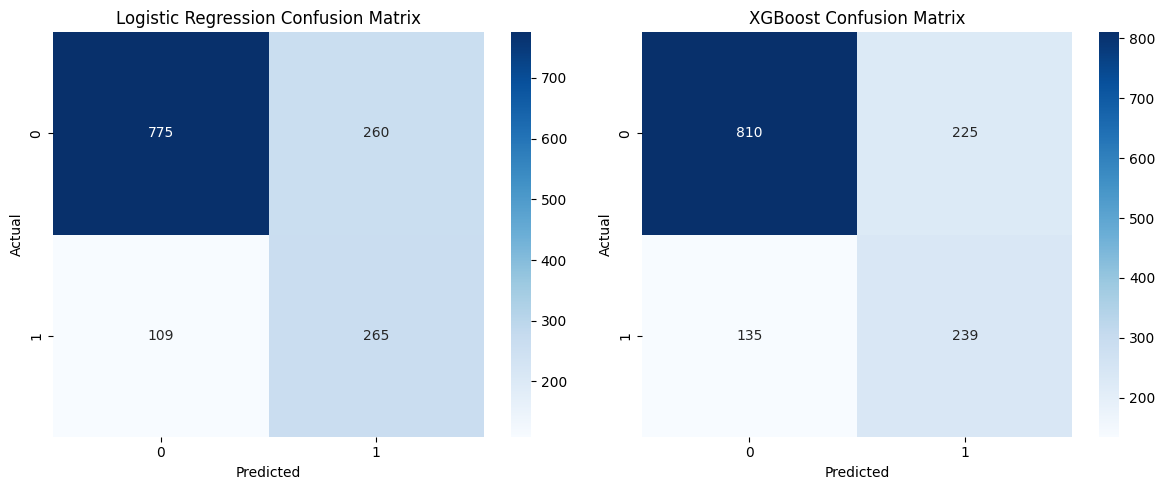


ROC AUC for Logistic Regression: 0.8213
ROC AUC for XGBoost: 0.8067


In [8]:
# Make predictions on the test set
y_pred_log_reg = log_reg.predict(X_test)
y_pred_xgb = xgb_clf.predict(X_test)

# Evaluate Logistic Regression
print("--- Logistic Regression Model Evaluation ---")
print(classification_report(y_test, y_pred_log_reg))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

# Evaluate XGBoost
print("\n--- XGBoost Model Evaluation ---")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# Optional: Plot Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Calculate and print ROC AUC Score
roc_auc_log_reg = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
roc_auc_xgb = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])
print(f"\nROC AUC for Logistic Regression: {roc_auc_log_reg:.4f}")
print(f"ROC AUC for XGBoost: {roc_auc_xgb:.4f}")

In [9]:

# Create a DataFrame with the test set and predictions
results_df = X_test.copy()
results_df['Actual_Churn'] = y_test
results_df['Predicted_Churn_LogReg'] = y_pred_log_reg
results_df['Predicted_Churn_XGB'] = y_pred_xgb

# Save the DataFrame to a CSV file
results_df.to_csv("/content/drive/My Drive/job doc/job project/credit fraud/telco_churn_predictions.csv", index=False)

print("Predictions saved to telco_churn_predictions.csv")



Predictions saved to telco_churn_predictions.csv


In [10]:
test_set_size = len(y_test)
total_size = len(df)
train_end_index = total_size - test_set_size

# 2. Extract ALL readable columns for the test set from the original data.
# This gives us the customer IDs and un-encoded features.
df_test_source = df.iloc[train_end_index:].reset_index(drop=True)

# 3. Create the combined DataFrame with all source features
df_combined = df_test_source.copy()

# 4. Add the model prediction columns
df_combined['Predicted_Churn_LogReg'] = y_pred_log_reg
df_combined['Predicted_Churn_XGB'] = y_pred_xgb

# 5. Clean the TotalCharges column (crucial for Tableau)
# Converts any non-numeric values (like ' ') to NaN, then Pandas/Tableau can handle it as numeric.
df_combined['TotalCharges'] = pd.to_numeric(df_combined['TotalCharges'], errors='coerce')

# 6. Save the enhanced, Tableau-ready file/content/tableau_ready_churn_data.csv
df_combined.to_csv("/content/drive/My Drive/job doc/job project/credit fraud/tableau_ready_churn_data.csv", index=False)

print("Tableau-ready data saved to tableau_ready_churn_data.csv for dashboard creation.")

Tableau-ready data saved to tableau_ready_churn_data.csv for dashboard creation.
